# Player form — 10-game rolling averages

**What this shows.** A hitter's recent form: per-game DraftKings fantasy points and batting
average, smoothed with a **10-game rolling window** (pandas). It uses the SDK's auto-paging
`.iter()` to collect the game log in one loop.

**Note on ordering.** The MLB per-game stat feed serves **newest rows first** (server sort is
`id DESC`, capped at 1000/page). We page it, drop any duplicate rows defensively, sort by game,
and chart the most recent games — so the x-axis reads left-to-right in time.

**Quota cost.** ~1–2k records (a star hitter's multi-season log). Under a ~10k budget.

> **Setup.** Install deps (`pip install -r requirements.txt` plus the editable SDK — see the
> [README](../README.md)) and export your key once:
>
> ```bash
> export STAT_API_KEY=sdb_xxxxxxxx_...
> ```
>
> The client reads `STAT_API_KEY` from the environment. To run against a local mirror instead of
> production, also set `STAT_API_BASE_URL` (e.g. `http://localhost:3399`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statapi import StatApi

api = StatApi()

PLAYER_ID = 1437   # Pete Alonso. Browse ids with api.mlb.players.list(team_id=...).
ROLL = 10          # rolling window, in games
RECENT = 60        # how many recent games to chart

## 1 · Who is this player

In [2]:
player = api.mlb.players.get(PLAYER_ID)
print(player["full_name"], "—", player["primary_position"], f"(bats {player['bats']})")

Pete Alonso — 1B (bats R)


## 2 · Walk the game log with the auto-pager

`.iter()` yields every row across pages — no manual cursor handling. We collect into a DataFrame,
drop duplicate rows on the primary key, and sort chronologically by `game_id`.

In [3]:
raw = list(api.mlb.game_player_batter_stats.iter(player_id=PLAYER_ID, limit=1000))
log = (
    pd.DataFrame(raw)
    .drop_duplicates("id")
    .sort_values("game_id")
    .reset_index(drop=True)
)
print(f"{len(log)} games collected")
log[["game_id", "at_bats", "hits", "home_runs", "runs_batted_in", "walks", "stolen_bases"]].tail()

1000 games collected


,game_id,at_bats,hits,home_runs,runs_batted_in,walks,stolen_bases
995,161264,4,3,0,2,1,0
996,162970,2,0,0,0,2,0
997,163055,4,1,0,1,1,0
998,163143,4,1,1,2,0,0
999,163158,4,0,0,0,0,0


## 3 · Per-game fantasy points + rolling averages

DraftKings MLB hitter scoring: single 3, double 5, triple 8, HR 10, RBI 2, run 2, walk 2,
hit-by-pitch 2, stolen base 5.

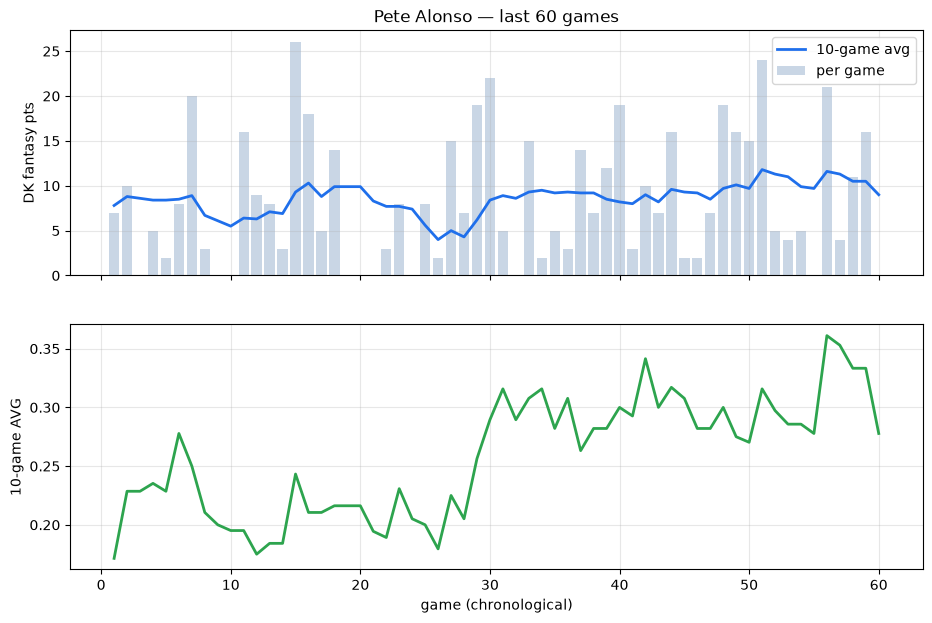

In [4]:
def dk_points(r):
    return (3 * r["singles"] + 5 * r["doubles"] + 8 * r["triples"] + 10 * r["home_runs"]
            + 2 * r["runs_batted_in"] + 2 * r["runs"] + 2 * r["walks"] + 2 * r["hit_by_pitch"]
            + 5 * r["stolen_bases"])

log["dk_pts"] = log.apply(dk_points, axis=1)
log[f"dk_roll{ROLL}"] = log["dk_pts"].rolling(ROLL).mean()
log["ba_roll"] = log["hits"].rolling(ROLL).sum() / log["at_bats"].rolling(ROLL).sum()

recent = log.tail(RECENT).reset_index(drop=True)
recent["game_no"] = recent.index + 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.bar(recent["game_no"], recent["dk_pts"], color="#c9d6e5", label="per game")
ax1.plot(recent["game_no"], recent[f"dk_roll{ROLL}"], color="#1f6feb", lw=2, label=f"{ROLL}-game avg")
ax1.set_ylabel("DK fantasy pts")
ax1.set_title(f"{player['full_name']} — last {RECENT} games")
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(recent["game_no"], recent["ba_roll"], color="#2da44e", lw=2)
ax2.set_ylabel(f"{ROLL}-game AVG")
ax2.set_xlabel("game (chronological)")
ax2.grid(alpha=0.3)
plt.show()

## 4 · Recent form table

In [5]:
recent[["game_no", "game_id", "hits", "home_runs", "runs_batted_in", "dk_pts", f"dk_roll{ROLL}"]].tail(12).round(1)

,game_no,game_id,hits,home_runs,runs_batted_in,dk_pts,dk_roll10
48,49,161094,1,1,2,16.0,10.1
49,50,161098,1,0,2,15.0,9.7
50,51,161113,3,1,2,24.0,11.8
51,52,161127,1,0,0,5.0,11.3
52,53,161164,0,0,0,4.0,11.0
53,54,161180,1,0,0,5.0,9.9
54,55,161184,0,0,0,0.0,9.7
55,56,161264,3,0,2,21.0,11.6
56,57,162970,0,0,0,4.0,11.3
57,58,163055,1,0,1,11.0,10.5


## Quota used

In [6]:
q = api.mlb.game_player_batter_stats.list(player_id=PLAYER_ID, limit=1).quota
print(f"Records remaining this month: {q.remaining:,} of {q.limit:,}")

Records remaining this month: 34,793 of 50,000
